In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from pathlib import Path

DATA_PATH = Path("../data/netflix_titles.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [33]:
df.shape

(8807, 12)

In [34]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [35]:
df.dropna(axis=0, how="any", inplace=True)

In [36]:
df.describe(include=["int64"])

,release_year
count,5332.000000
mean,2012.742123
std,9.625831
min,1942.000000
25%,2011.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


In [37]:
# checking missing values
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [38]:

# fix columns
df.columns = df.columns.str.replace("_", " ")
df.columns = df.columns.str.capitalize()

In [39]:
df.Country = df.Country.str.split(",")
df = df.explode("Country")
df.Country = df.Country.str.strip()


In [40]:
df["Listed in"] = df["Listed in"].str.split(",")
df = df.explode("Listed in")
df["Listed in"] = df["Listed in"].str.strip()

In [41]:
df.Director = df.Director.str.split(",")
df = df.explode("Director")
df.Director = df.Director.str.strip()

In [42]:
# new dataframe
df.head()

,Show id,Type,Title,Director,Cast,Country,Date added,Release year,Rating,Duration,Listed in,Description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,24-Sep-21,1993,TV-MA,125 min,Dramas,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,24-Sep-21,1993,TV-MA,125 min,Independent Movies,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,24-Sep-21,1993,TV-MA,125 min,International Movies,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,24-Sep-21,1993,TV-MA,125 min,Dramas,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",Ghana,24-Sep-21,1993,TV-MA,125 min,Independent Movies,"On a photo shoot in Ghana, an American model s..."


## Movies vs. Tv Shows

More movies or tv shows?


In [43]:
type_counts = df["Type"].value_counts()

Text(0.5, 1.0, 'Netflix Movie Counts')

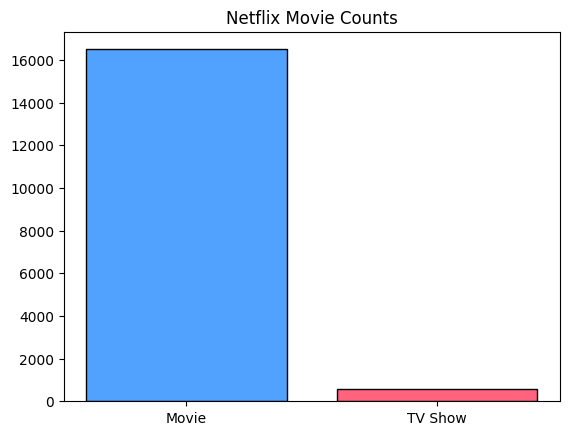

In [44]:
labels = ["Movie", "TV Show"]
counts = [type_counts.Movie, type_counts["TV Show"]]
type_colors = ["#51a2ff", "#ff637e"]
plt.bar(labels, counts, label=labels, color=type_colors, ec="black")
plt.title("Netflix Movie Counts")

What % is each?

([<matplotlib.patches.Wedge at 0x1e99f605310>,
 [Text(-1.1933158175640768, 0.12648066868648036, 'Movie'),
  Text(1.0938728705452592, -0.11594025653359033, 'TV Show')],
 [Text(-0.6961008935790448, 0.07378039006711354, '96.6%'),
  Text(0.5966579293883232, -0.0632401399274129, '3.4%')])

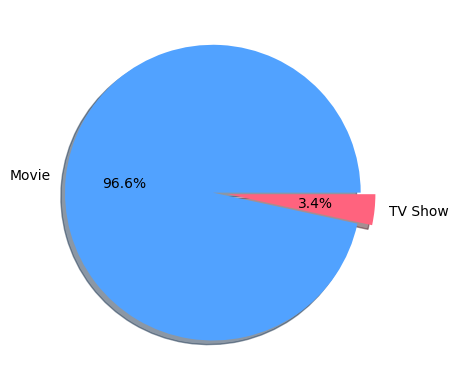

In [45]:
type_counts_perc = df["Type"].value_counts(normalize=True, dropna=True)
type_counts_perc_values = [type_counts_perc.Movie, type_counts_perc["TV Show"]]

plt.pie(type_counts_perc_values, labels=labels, autopct="%1.1f%%", colors=type_colors, explode=(0.1, 0), shadow=True)

## Content Growth Over Time


When did Netflix rapidly expand?

In [46]:
df.groupby("Release year").size()

Release year
1942       2
1944      20
1945       4
1946       2
1947       4
        ... 
2017    1924
2018    2120
2019    1551
2020    1206
2021     497
Length: 72, dtype: int64

Which years had the most releases?

Text(0.5, 1.0, 'Years with the most releases')

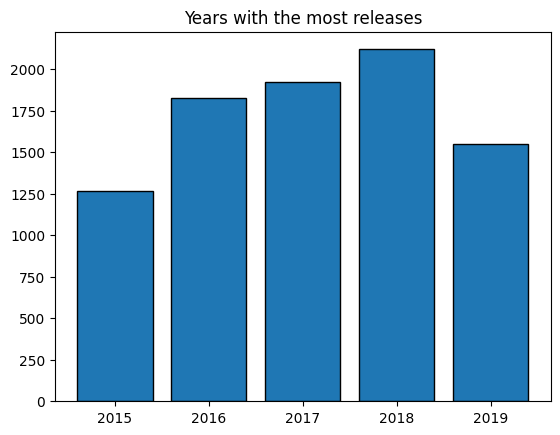

In [47]:
most_releases = df.groupby("Release year").size().nlargest(5)

plt.bar(most_releases.index, most_releases.values, ec="black")
plt.title("Years with the most releases")

Did TV Shows grow faster than movies over the last years?

In [48]:
df["Date added"] = pd.to_datetime(df["Date added"], errors="coerce", format="%B %d, %Y")
# min. and max. date added
max_year_added = df["Date added"].dt.year.max()
min_year_added = df["Date added"].dt.year.min()
print(max_year_added, min_year_added)

nan nan


Text(0.5, 0.98, 'Released titles')

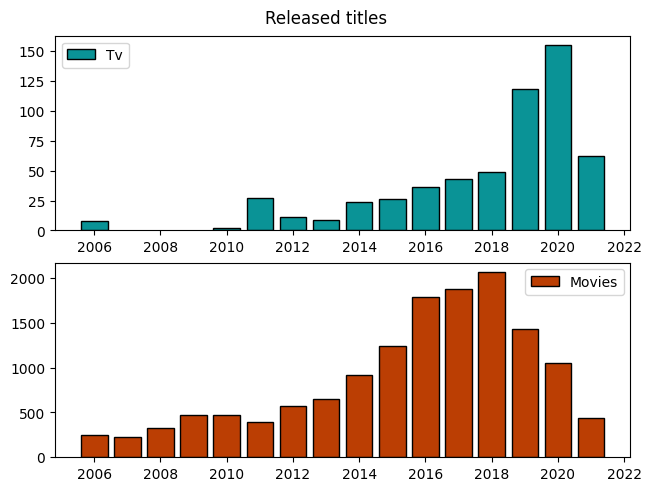

In [49]:

tv_shows_df = df[(df.Type == "TV Show") & (df["Release year"] > 2005)].groupby("Release year").size()
movies_df = df[(df.Type == "Movie") & (df["Release year"] > 2005)].groupby("Release year").size()

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True)
axes[0].bar(tv_shows_df.index, tv_shows_df.values, color="#0A9396", edgecolor="black", label="Tv")
axes[0].legend()
axes[1].bar(movies_df.index, movies_df.values, color="#BB3E03", edgecolor="black", label="Movies")
axes[1].legend()
plt.suptitle("Released titles")




## Top Countries Producing Netflix Content

Which countries dominate Netflix?

Text(0.5, 1.0, 'Most dominating countries')

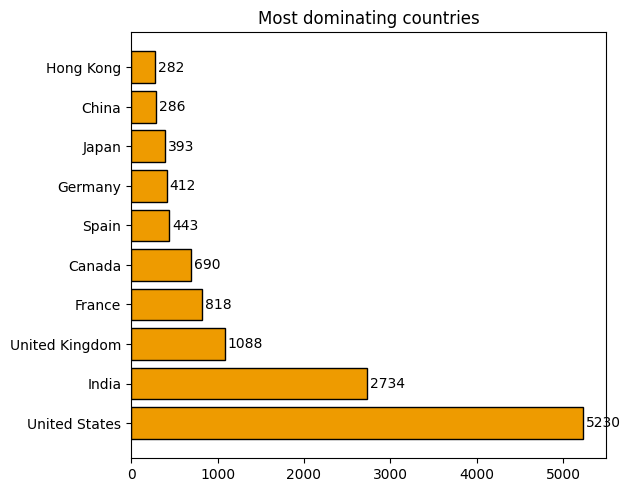

In [50]:
top_ten_countries = df.Country.value_counts().nlargest(10)
bar_h = plt.barh(top_ten_countries.index, top_ten_countries.values, color="#EE9B00", edgecolor="black")
bar_label = plt.bar_label(bar_h, padding=2)
plt.tight_layout()
plt.title("Most dominating countries")


Which countries focus more on TV vs movies?

Text(0.5, 0.98, 'Movies are preferred')

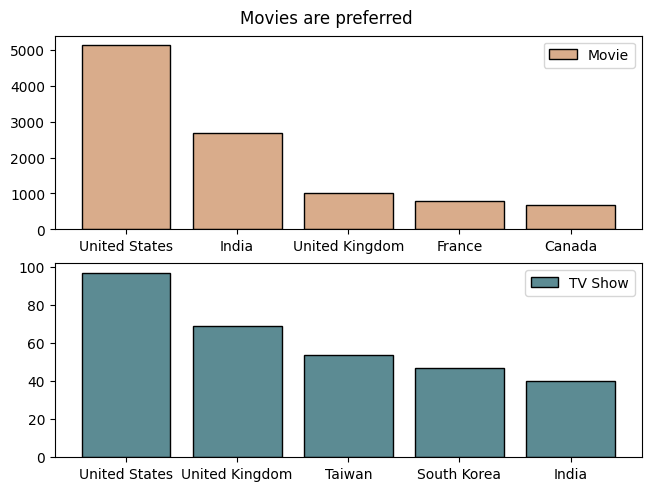

In [51]:
country_type = df.groupby(["Country", "Type"]).size()
country_type = country_type.unstack()
country_type_movie_largest = country_type.Movie.nlargest(5)
country_type_tv_largest = country_type["TV Show"].nlargest(5)

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True)

axes[0].bar(country_type_movie_largest.index, country_type_movie_largest.values, label="Movie", color="#d9ac8b", edgecolor="black")
axes[0].legend()

axes[1].bar(country_type_tv_largest.index, country_type_tv_largest.values, label="TV Show", color="#5c8b93", edgecolor="black")
axes[1].legend()

plt.suptitle("Movies are preferred")


## Most Commong Ratings

Which ratings appear most often?

Text(0, 0.5, 'Count')

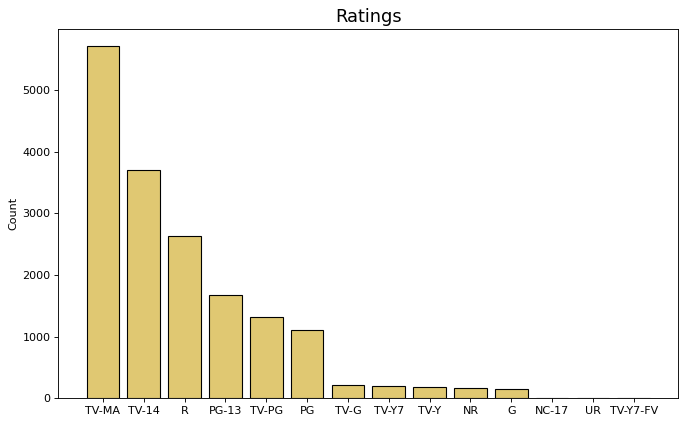

In [52]:
ratings = df.Rating.value_counts()

figure(figsize=(10, 6), dpi=80)
plt.bar(ratings.index, ratings.values, color="#e0c872", edgecolor="black")
plt.title("Ratings", fontsize=16)
plt.ylabel("Count")

Is Netflix mostly adult or family content?

Text(0, 0.5, '%')

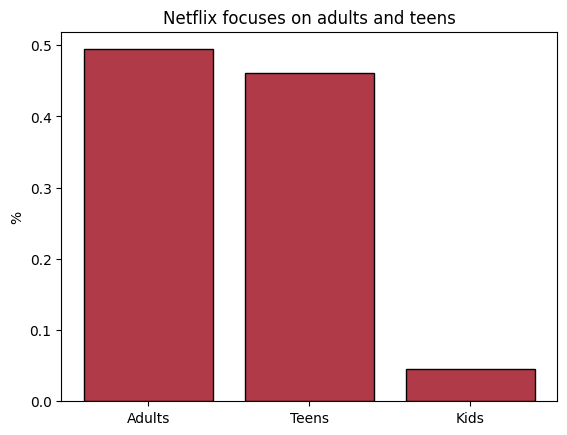

In [53]:
rating_categories = {
    "TV-Y": "Kids",
    "TV-Y7": "Kids",
    "G": "Kids",
    "TV-G": "Kids",
    
    "PG": "Teens",
    "PG-13": "Teens",
    "TV-PG": "Teens",
    "TV-14": "Teens",
    
    "R": "Adults",
    "TV-MA": "Adults",
    "NC-17": "Adults",
}

df["Rating category"] = df.Rating.map(rating_categories)
rating_cats = df["Rating category"].value_counts(normalize=True)

plt.bar(rating_cats.index, rating_cats.values, color="#b03a48", edgecolor="black")
plt.title("Netflix focuses on adults and teens")
plt.ylabel("%")

## Duration Analysis

Movies And Tv Show Statistics

In [54]:
# extract numbers first
df["Duration num"] = df.Duration.str.extract('(\d+)')
df["Duration num"] = df["Duration num"].astype(int)

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\chris\AppData\Local\Temp\ipykernel_11232\1054330331.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["Duration num"] = df.Duration.str.extract('(\d+)')


Text(0.5, 0.98, 'Type statistics')

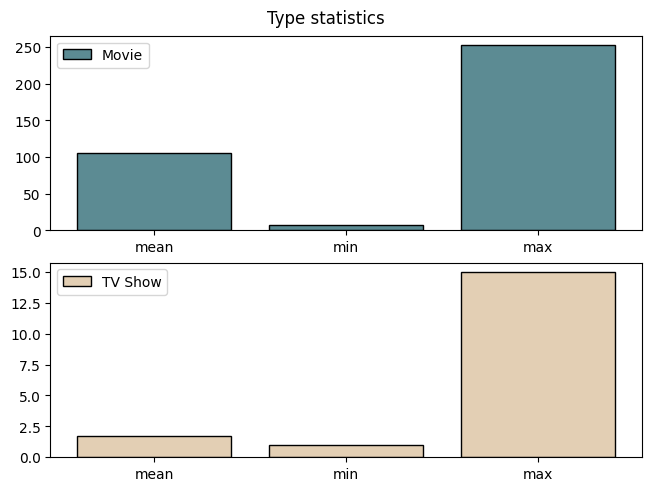

In [55]:
movies = df[df.Type == "Movie"]
tv_shows = df[df.Type == "TV Show"]
movies_stats = movies["Duration num"].agg(["mean", "min", "max"])
tv_shows_stats = tv_shows["Duration num"].agg(["mean", "min", "max"])

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True)

axes[0].bar(movies_stats.index, movies_stats.values, color="#5c8b93", edgecolor="black", label="Movie")
axes[0].legend()

axes[1].bar(tv_shows_stats.index, tv_shows_stats.values, color="#e3cfb4", edgecolor="black", label="TV Show")
axes[1].legend()

plt.suptitle("Type statistics")

## Genre Analysis

Most common genres? Are dramas more common than comedies?

In [56]:
most_common_genres = df["Listed in"].value_counts().nlargest(10)
most_common_genres

Listed in
Dramas                      3308
International Movies        3287
Comedies                    2082
Action & Adventure          1244
Independent Movies          1140
Children & Family Movies     901
Thrillers                    812
Romantic Movies              712
Documentaries                588
Horror Movies                493
Name: count, dtype: int64

Text(0.5, 1.0, 'Most common genres')

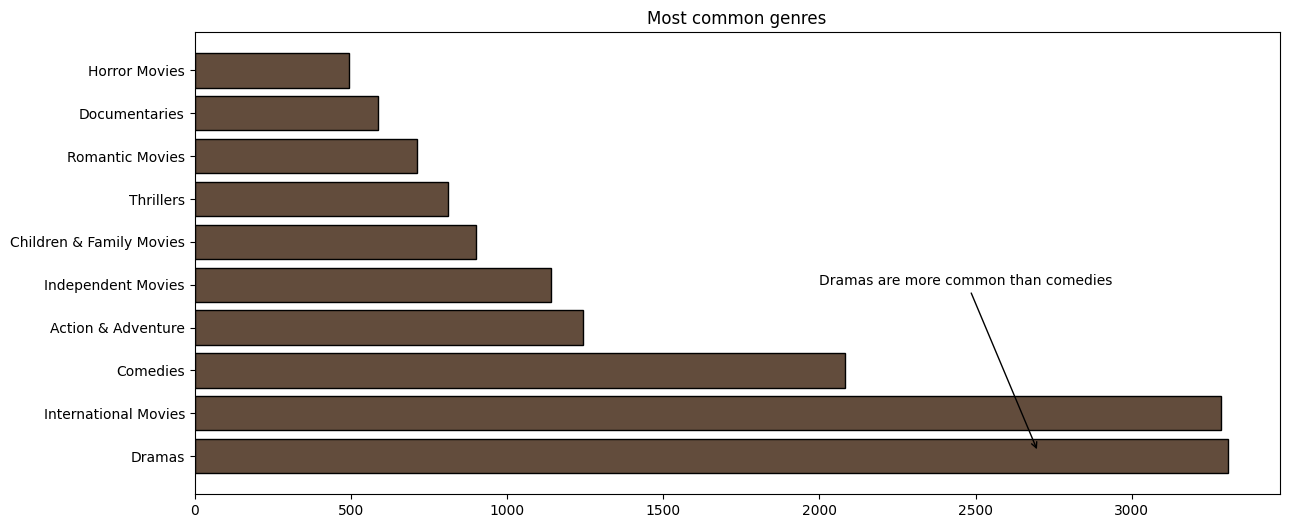

In [57]:
figure(figsize=(14, 6))
plt.barh(most_common_genres.index, most_common_genres.values, color="#624c3c", edgecolor="black")
plt.annotate(text="Dramas are more common than comedies", xytext=(2000, 4), xy=(2700, 0.1), arrowprops=dict(arrowstyle="->"))
plt.title("Most common genres")


## Director Analysis

Who are the most common directors?

Text(0.5, 1.0, 'Most common directors')

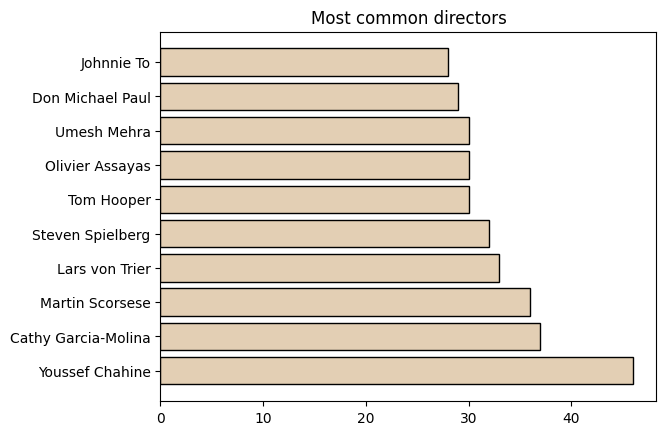

In [58]:
most_common_directors = df.Director.value_counts().nlargest(10)
most_common_directors

plt.barh(most_common_directors.index, most_common_directors.values, color="#e3cfb4", edgecolor="black")
plt.title("Most common directors")

Which directors do both movies and tv shows?

In [59]:
director_types = df.groupby("Director")["Type"].nunique()
both = director_types[director_types == 2]
both = both.reset_index()
both.head(20)

,Director,Type
0,Alastair Fothergill,2
1,Andrew Tan,2
2,Anurag Kashyap,2
3,B. V. Nandini Reddy,2
4,BB Sasore,2
5,Bejoy Nambiar,2
6,Eli Roth,2
7,Faris Godus,2
8,Gary Howsam,2
9,Hiroyuki Seshita,2


## Content Growth By Country (US vs India)

Text(0.5, 0.98, 'Content Growth')

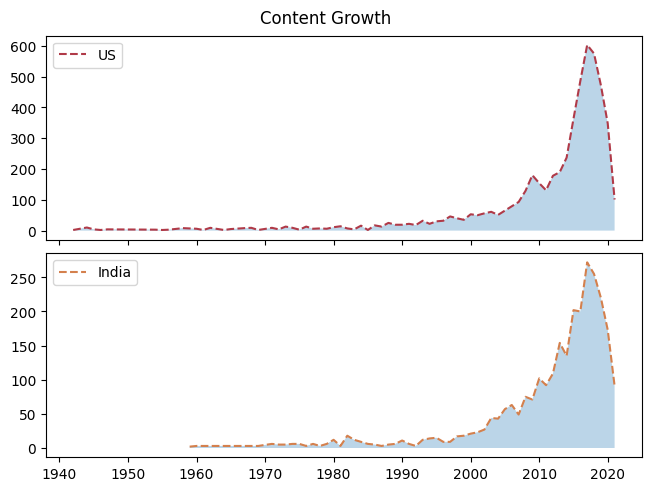

In [60]:
us_counts_by_year = df[df.Country == "United States"].groupby("Release year").size()
india_counts_by_year = df[df.Country == "India"].groupby("Release year").size()

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, constrained_layout=True, sharex=True)

ax1.plot(us_counts_by_year.index, us_counts_by_year.values, linewidth=1.5, linestyle="dashed", color="#b03a48", label="US")
ax1.fill_between(us_counts_by_year.index, us_counts_by_year.values, alpha=0.3)
ax1.legend()
ax2.plot(india_counts_by_year.index, india_counts_by_year.values, linewidth=1.5, linestyle="dashed", color="#d4804d", label="India")
ax2.fill_between(india_counts_by_year.index, india_counts_by_year.values, alpha=0.3)
ax2.legend()


plt.suptitle("Content Growth")

## CONCLUSIONS



1. Netflix issues more movies than tv shows, 96.6% vs. 3.4%, respectively.
2. Netflix rapidly expanded after the 2010s, particularly after 2015, issuing more than 1000 movies and tv series per year.
3. The US is the country that produces the most Netflix content, followed by India and the United Kingdom. 
4. The most common ratings are TV-MA, TV-14 and R. Talking about ratings categories, Netflix focuses on adults and teens; in fact, less than 10% of the content is for kids.
5. Movies’ average duration is slightly more than 100 minutes while tv shows’ average duration is 1.75 seasons.
6. The most common genres are dramas, international movies and comedies. Of particular note, dramas are more common than comedies.
7. The most common directors are Youssef Chahine and Cathy Garcia-Molina. 
8. Both the US and India have experienced a huge amount of content growth, with the most titles released in the last few years.
